# Reproduction et analyse de Nucleus Sampling (Holtzman et al., ICLR 2020)

**Projet** : *The Curious Case of Neural Text Degeneration*

Ce notebook implémente **Nucleus Sampling** (top-p) à partir de zéro et explore deux dimensions expérimentales clés du papier :

1. **Expérience principale** — Le phénomène de dégénération : on mesure le taux de répétition des générations en fonction du paramètre de chaque méthode de décodage. Reproduction simplifiée de la Figure 9 du papier.
2. **Expérience secondaire** — La dynamique du nucléus : on visualise comment la taille du nucléus $|V^{(p)}|$ varie au cours d'une génération, ce qui justifie l'avantage du top-p sur le top-k (argument central du papier, Figure 5).

**Modèle utilisé** : GPT-2 small (ou medium) (124M paramètres ou 355M), soit 6× plus petit que le GPT-2 Large du papier. Cela permet d'exécuter l'expérience sur un Colab gratuit en quelques minutes (avec GPU) ou ~30 minutes (CPU). Si le phénomène se reproduit même à cette échelle, cela renforce la thèse du papier selon laquelle **la dégénération est un défaut intrinsèque du décodage par maximisation**, pas un artefact de modèle.


## 1. Installation et imports

In [1]:
# Décommenter sur Colab si nécessaire
# !pip install -q torch transformers matplotlib numpy

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import time

from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Détection automatique du device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda


## 2. Chargement du modèle GPT-2

In [2]:
MODEL_NAME = "gpt2-medium"  # 124M params. Variante : "gpt2-medium" (355M) si GPU disponible

tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

# Le tokenizer GPT-2 n'a pas de pad token par défaut
tokenizer.pad_token = tokenizer.eos_token

n_params = sum(p.numel() for p in model.parameters())
print(f"Modèle chargé : {MODEL_NAME} ({n_params/1e6:.1f}M paramètres)")
print(f"Taille du vocabulaire : {tokenizer.vocab_size}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Modèle chargé : gpt2-medium (354.8M paramètres)
Taille du vocabulaire : 50257


## 3. Implémentation des méthodes de décodage

On implémente les quatre stratégies à partir de zéro pour bien comprendre leur fonctionnement.

### 3.1 Nucleus Sampling (Top-p)

**Définition formelle (équation 2 du papier)** : pour une distribution $P(x \mid x_{<i})$, on définit le **vocabulaire top-p** $V^{(p)} \subset V$ comme **le plus petit ensemble** tel que :

$$\sum_{x \in V^{(p)}} P(x \mid x_{<i}) \geq p$$

Puis on renormalise sur $V^{(p)}$ et on échantillonne.


In [3]:
def nucleus_sampling(logits: torch.Tensor, p: float = 0.95) -> torch.Tensor:
    """Échantillonne un token selon Nucleus Sampling (top-p).

    Args:
        logits: tenseur 1D de taille |V| (logits non normalisés)
        p: seuil de masse de probabilité (entre 0 et 1)

    Returns:
        Tenseur 1D contenant l'indice du token sélectionné.
    """
    # 1. Trier les logits par ordre décroissant
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)

    # 2. Calculer les probabilités cumulées
    sorted_probs = F.softmax(sorted_logits, dim=-1)
    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

    # 3. Identifier les tokens à exclure (au-delà du seuil p)
    #    On veut le PLUS PETIT ensemble dont la masse >= p,
    #    donc on garde aussi le token qui fait basculer au-dessus de p.
    sorted_indices_to_remove = cumulative_probs > p
    sorted_indices_to_remove[1:] = sorted_indices_to_remove[:-1].clone()
    sorted_indices_to_remove[0] = False  # Toujours garder le token le plus probable

    # 4. Construire les logits filtrés
    indices_to_remove = sorted_indices[sorted_indices_to_remove]
    filtered_logits = logits.clone()
    filtered_logits[indices_to_remove] = float('-inf')

    # 5. Renormaliser et échantillonner
    probs = F.softmax(filtered_logits, dim=-1)
    return torch.multinomial(probs, num_samples=1)

### 3.2 Top-k Sampling

On garde les $k$ tokens les plus probables, renormalisation, échantillonnage.

In [4]:
def top_k_sampling(logits: torch.Tensor, k: int = 40) -> torch.Tensor:
    """Top-k sampling."""
    top_k_logits, top_k_indices = torch.topk(logits, k)
    probs = F.softmax(top_k_logits, dim=-1)
    sampled_local_idx = torch.multinomial(probs, num_samples=1)
    return top_k_indices[sampled_local_idx]

### 3.3 Boucle de génération autoregressive

Génération token par token, applicable à toutes les méthodes.

In [5]:
@torch.no_grad()
def generate(prompt: str, method: str, max_new_tokens: int = 100,
             temperature: float = 1.0, p: float = 0.95, k: int = 40) -> str:
    """Génère une continuation pour un prompt donné, selon la méthode spécifiée.

    Args:
        prompt: texte initial
        method: 'greedy', 'sampling', 'topk', 'nucleus', 'temperature'
        max_new_tokens: nombre max de tokens à générer
        temperature, p, k: hyperparamètres selon la méthode

    Returns:
        Le texte généré (sans le prompt initial).
    """
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    prompt_len = input_ids.shape[1]

    for _ in range(max_new_tokens):
        logits = model(input_ids).logits[0, -1, :]

        # Application de la température (sauf greedy)
        if temperature != 1.0 and method != 'greedy':
            logits = logits / temperature

        # Sélection du token suivant
        if method == 'greedy':
            next_token = torch.argmax(logits).unsqueeze(0)
        elif method == 'sampling' or method == 'temperature':
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
        elif method == 'topk':
            next_token = top_k_sampling(logits, k=k)
        elif method == 'nucleus':
            next_token = nucleus_sampling(logits, p=p)
        else:
            raise ValueError(f"Méthode inconnue : {method}")

        input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=-1)

        if next_token.item() == tokenizer.eos_token_id:
            break

    return tokenizer.decode(input_ids[0, prompt_len:], skip_special_tokens=True)

### 3.4 Vérification rapide : comparaison qualitative des méthodes

Avant de lancer l'expérience quantitative, on regarde ce que produit chaque méthode sur le même prompt.

In [6]:
torch.manual_seed(SEED)
demo_prompt = "In a shocking finding, scientists discovered"

print(f"Prompt : {demo_prompt!r}\n")

for method, params in [
    ('greedy', {}),
    ('sampling', {}),
    ('topk', {'k': 40}),
    ('nucleus', {'p': 0.95}),
]:
    torch.manual_seed(SEED)  # même seed pour comparaison équitable
    out = generate(demo_prompt, method, max_new_tokens=60, **params)
    print(f"--- {method} {params} ---")
    print(out[:300])
    print()

Prompt : 'In a shocking finding, scientists discovered'

--- greedy {} ---
 that the brain of a man who died of a heart attack in the early 1990s was not as healthy as it should have been.

The man, who was in his late 40s, had a heart attack in his early 20s and died in hospital.

The findings, published

--- sampling {} ---
 for the first time in 33,000 years that the ancient sea animals suffered from sea sickness at sea, which would make them more susceptible to the disease.

Lead researcher Dr Steven Koustovsky noted in the British Endurance and River Science conference in London that the infections would have been m

--- topk {'k': 40} ---
 that the body's own fat stored for five years of life could even grow on the surface of your own body. They say this is the first evidence of our bodies changing their internal clock with age, making them unable to react as readily or quickly to emergencies.

The findings, published in Scientific

--- nucleus {'p': 0.95} ---
 for the first time

## 4. Détection de répétition

On reproduit la métrique de la Figure 9 du papier : une génération est considérée comme **dégénérée** si une phrase de longueur ≥ 2 mots apparaît **≥ 3 fois consécutivement en fin de texte**.

*Note : le papier travaille au niveau des tokens BPE, on travaille ici au niveau des mots (séparation par espaces). C'est une simplification raisonnable pour notre échelle.*

In [7]:
def has_repetition(text: str, min_phrase_len: int = 2, max_phrase_len: int = 15,
                    min_repeats: int = 3) -> bool:
    """Détecte si le texte se termine par une phrase répétée >= min_repeats fois.

    Suit la définition de la Figure 9 du papier (Holtzman et al., 2020).
    """
    tokens = text.split()
    n = len(tokens)
    if n < min_phrase_len * min_repeats:
        return False

    for phrase_len in range(min_phrase_len, min(max_phrase_len + 1, n // min_repeats + 1)):
        # Phrase candidate : les derniers `phrase_len` mots
        last_phrase = tokens[-phrase_len:]
        count = 1
        # On remonte en arrière par blocs de `phrase_len`
        for start in range(n - 2 * phrase_len, -1, -phrase_len):
            if tokens[start:start + phrase_len] == last_phrase:
                count += 1
            else:
                break
        if count >= min_repeats:
            return True
    return False

# Tests unitaires
assert has_repetition("a b c the cat the cat the cat") == True
assert has_repetition("a b c d e f g h") == False
assert has_repetition("hello world hello world hello world") == True
print("Tests de répétition OK")

Tests de répétition OK


## 5. Prompts pour l'expérience

On utilise une sélection de débuts de phrases variés inspirés de WebText (corpus d'entraînement de GPT-2). On en met 20 — c'est peu mais suffisant pour observer les tendances. L'utilisateur peut augmenter ce nombre s'il a un GPU.

In [9]:
"""PROMPTS = [
    "In a shocking finding, scientists discovered",
    "The President announced today that",
    "Last night, on the corner of Main Street,",
    "The new policy on immigration will",
    "Researchers at the university have developed",
    "The quick brown fox jumped over",
    "After three years of investigation,",
    "The latest study published in Nature shows",
    "It was a dark and stormy night when",
    "The economy of the country has",
    "In the middle of the forest, there lived",
    "The committee voted unanimously to",
    "During the summer of 1969,",
    "The new restaurant downtown serves",
    "Climate change is affecting",
    "My grandfather used to tell me that",
    "The CEO of the company stated that",
    "On the first day of school,",
    "The ancient ruins were discovered by",
    "In her latest interview, the actress said",
]
print(f"Nombre de prompts : {len(PROMPTS)}")"""

from datasets import load_dataset
ds = load_dataset("Salesforce/wikitext", "wikitext-103-v1", split="test")
# Filtrer les paragraphes de taille raisonnable et prendre les 30 premiers tokens
PROMPTS = []
for ex in ds:
    text = ex['text'].strip()
    if len(text.split()) > 50 and not text.startswith('='):
        tokens = tokenizer.encode(text)[:30]
        PROMPTS.append(tokenizer.decode(tokens))
    if len(PROMPTS) >= 100:
        break

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-103-v1/test-00000-of-00001.parq(…):   0%|          | 0.00/722k [00:00<?, ?B/s]

wikitext-103-v1/train-00000-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

wikitext-103-v1/train-00001-of-00002.par(…):   0%|          | 0.00/156M [00:00<?, ?B/s]

wikitext-103-v1/validation-00000-of-0000(…):   0%|          | 0.00/655k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

## 6. Expérience principale : taux de répétition vs paramètre

Pour chaque méthode et chaque valeur de paramètre, on génère des continuations pour les 20 prompts et on calcule la fraction qui se termine en répétition. C'est une **reproduction simplifiée de la Figure 9 du papier**.

**Configuration** :
- 4 méthodes : greedy (point unique), top-k, top-p (nucleus), température
- Plusieurs valeurs par méthode
- 100 tokens générés par échantillon

**Coût estimé** :
- ~15 conditions × 20 prompts × 100 tokens = 30 000 forward passes
- ~25 minutes sur CPU Colab, ~3 minutes sur GPU T4.

In [10]:
MAX_TOKENS = 200  # longueur de génération

# Définition des conditions expérimentales
conditions = []
# Greedy : point unique
conditions.append(('greedy', 'greedy', 0.0, {}))
# Top-k : on balaye k
for k in [5, 10, 40, 100, 640]:
    conditions.append(('topk', f'top-k={k}', k, {'k': k}))
# Nucleus : on balaye p
for p in [0.5, 0.7, 0.9, 0.95, 0.99]:
    conditions.append(('nucleus', f'top-p={p}', p, {'p': p}))
# Température : on balaye t
for t in [0.3, 0.5, 0.7, 0.9, 1.0]:
    conditions.append(('temperature', f't={t}', t, {'temperature': t}))

print(f"Nombre de conditions : {len(conditions)}")
print(f"Nombre total de générations : {len(conditions) * len(PROMPTS)}")

Nombre de conditions : 16
Nombre total de générations : 1600


In [12]:
# Boucle principale
results = []  # liste de dicts : {method, label, param, repetition_rate, n}

t_start = time.time()
for cond_idx, (method, label, param_val, params) in enumerate(conditions):
    n_repetition = 0
    for prompt_idx, prompt in enumerate(PROMPTS):
        # Seed déterministe : même pour tous les prompts d'une même condition,
        # différent entre les prompts pour avoir des échantillons distincts.
        torch.manual_seed(SEED + prompt_idx)
        out = generate(prompt, method, max_new_tokens=MAX_TOKENS, **params)
        if has_repetition(out):
            n_repetition += 1

    rate = n_repetition / len(PROMPTS)
    results.append({
        'method': method, 'label': label, 'param': param_val,
        'repetition_rate': rate, 'n_rep': n_repetition, 'n_total': len(PROMPTS),
    })
    elapsed = time.time() - t_start
    print(f"[{cond_idx+1:2d}/{len(conditions)}] {label:15s} -> {n_repetition:2d}/{len(PROMPTS)} ({rate*100:5.1f}%) [t={elapsed:.0f}s]")

print(f"\nTemps total : {(time.time()-t_start)/60:.1f} min")

[ 1/16] greedy          -> 23/100 ( 23.0%) [t=837s]
[ 2/16] top-k=5         ->  0/100 (  0.0%) [t=1606s]
[ 3/16] top-k=10        ->  0/100 (  0.0%) [t=2381s]
[ 4/16] top-k=40        ->  0/100 (  0.0%) [t=3139s]
[ 5/16] top-k=100       ->  0/100 (  0.0%) [t=3902s]
[ 6/16] top-k=640       ->  0/100 (  0.0%) [t=4639s]
[ 7/16] top-p=0.5       ->  4/100 (  4.0%) [t=5396s]
[ 8/16] top-p=0.7       ->  0/100 (  0.0%) [t=6155s]
[ 9/16] top-p=0.9       ->  0/100 (  0.0%) [t=6886s]
[10/16] top-p=0.95      ->  0/100 (  0.0%) [t=7634s]
[11/16] top-p=0.99      ->  0/100 (  0.0%) [t=8350s]
[12/16] t=0.3           -> 23/100 ( 23.0%) [t=9155s]
[13/16] t=0.5           -> 15/100 ( 15.0%) [t=9962s]
[14/16] t=0.7           ->  1/100 (  1.0%) [t=10730s]
[15/16] t=0.9           ->  0/100 (  0.0%) [t=11469s]
[16/16] t=1.0           ->  0/100 (  0.0%) [t=12213s]

Temps total : 203.6 min


In [13]:
# Sauvegarde des résultats bruts (utile pour le rapport)
import json
with open('results_experiment_1.json', 'w') as f:
    json.dump(results, f, indent=2)
print("Résultats sauvegardés dans results_experiment_1.json")

Résultats sauvegardés dans results_experiment_1.json


### 6.1 Visualisation des résultats

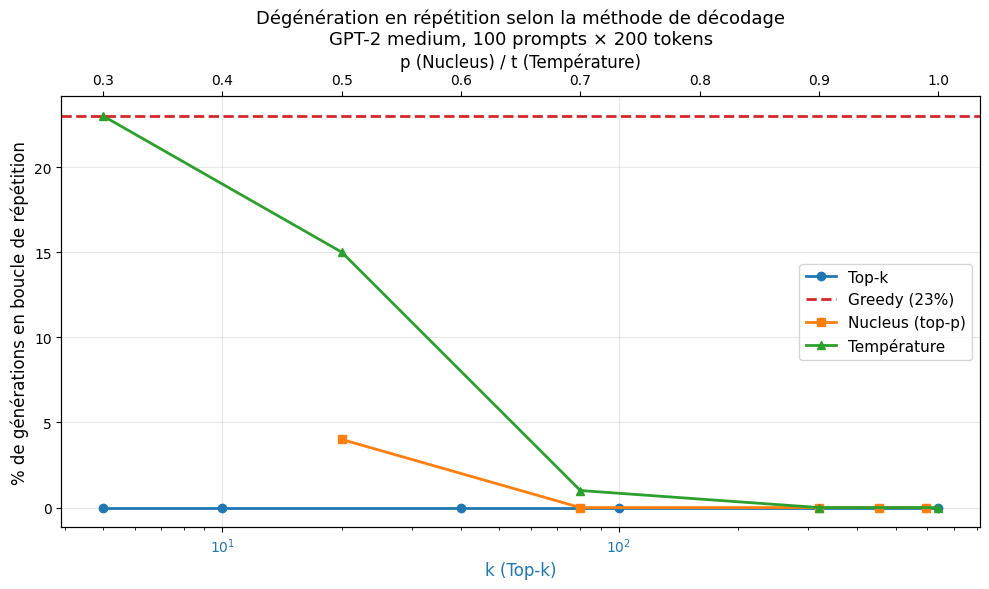

In [14]:
# Préparation des données par méthode
by_method = defaultdict(list)
for r in results:
    by_method[r['method']].append(r)

fig, ax = plt.subplots(figsize=(10, 6))

# Top-k : abscisse en log
topk = sorted(by_method['topk'], key=lambda r: r['param'])
ax.plot([r['param'] for r in topk], [r['repetition_rate']*100 for r in topk],
        marker='o', label='Top-k', color='C0', linewidth=2)

# Nucleus : abscisse linéaire mais paramètre dans [0,1]
nuc = sorted(by_method['nucleus'], key=lambda r: r['param'])
# Pour superposer top-k et nucleus, on plotte sur un axe secondaire
ax2 = ax.twiny()
ax2.plot([r['param'] for r in nuc], [r['repetition_rate']*100 for r in nuc],
         marker='s', label='Nucleus (top-p)', color='C1', linewidth=2)

# Température : abscisse dans [0,1]
temp = sorted(by_method['temperature'], key=lambda r: r['param'])
ax2.plot([r['param'] for r in temp], [r['repetition_rate']*100 for r in temp],
         marker='^', label='Température', color='C2', linewidth=2)

# Greedy : ligne horizontale
greedy_rate = by_method['greedy'][0]['repetition_rate'] * 100
ax.axhline(greedy_rate, color='C3', linestyle='--', linewidth=2,
           label=f'Greedy ({greedy_rate:.0f}%)')

ax.set_xscale('log')
ax.set_xlabel('k (Top-k)', color='C0', fontsize=12)
ax2.set_xlabel('p (Nucleus) / t (Température)', fontsize=12)
ax.set_ylabel('% de générations en boucle de répétition', fontsize=12)
ax.set_title('Dégénération en répétition selon la méthode de décodage\n'
             f'GPT-2 medium, {len(PROMPTS)} prompts × {MAX_TOKENS} tokens',
             fontsize=13)
ax.tick_params(axis='x', labelcolor='C0')
ax.grid(True, alpha=0.3)

# Légende combinée
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=11)

plt.tight_layout()
plt.savefig('repetition_curve.png', dpi=150, bbox_inches='tight')
plt.show()

**Lecture du graphique attendue** :
- *Greedy* devrait afficher un taux de répétition très élevé (50-80%), proche du 73% du papier.
- *Top-k* à petit k (k=5) → forte répétition ; à grand k → faible répétition.
- *Nucleus* dans sa plage usuelle p ∈ [0.9, 0.95] → faible répétition, proche du taux humain (0.28% dans le papier).
- *Température* < 0.7 → répétition importante (sur-troncature comme greedy).

Si le pattern qualitatif se reproduit sur GPT-2 small (124M), cela confirme la thèse du papier : la dégénération est un défaut structurel et non un artefact de modèle.

## 7. Expérience bonus : dynamique de la taille du nucléus

C'est l'argument central du papier visualisé : **la taille de la zone de confiance d'un LM varie énormément selon le contexte**. Top-k avec un k fixe ne peut pas capturer cette variation, contrairement à top-p.

On génère du texte avec p=0.95 et on trace la taille $|V^{(p)}|$ à chaque pas de temps.

In [15]:
def compute_nucleus_size(logits: torch.Tensor, p: float = 0.95) -> int:
    """Renvoie |V^(p)| : le nombre de tokens dans le nucléus."""
    sorted_probs = F.softmax(torch.sort(logits, descending=True).values, dim=-1)
    cumulative = torch.cumsum(sorted_probs, dim=-1)
    # On compte les tokens dont la masse cumulée n'a pas encore dépassé p, plus celui qui fait basculer.
    return int((cumulative <= p).sum().item()) + 1

@torch.no_grad()
def generate_with_nucleus_tracking(prompt: str, p: float = 0.95,
                                    max_new: int = 80) -> tuple[list[int], list[str]]:
    """Génère du texte avec nucleus sampling et enregistre |V^(p)| à chaque pas.

    Returns:
        - liste des tailles |V^(p)| pour chaque token généré
        - liste des tokens générés (mots décodés un par un)
    """
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    prompt_len = input_ids.shape[1]
    nucleus_sizes = []
    generated_tokens = []

    for _ in range(max_new):
        logits = model(input_ids).logits[0, -1, :]
        nucleus_sizes.append(compute_nucleus_size(logits, p))
        next_token = nucleus_sampling(logits, p=p)
        generated_tokens.append(tokenizer.decode([next_token.item()]))
        input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=-1)
        if next_token.item() == tokenizer.eos_token_id:
            break

    return nucleus_sizes, generated_tokens

In [16]:
# On lance la génération avec tracking sur quelques prompts
TRACK_PROMPTS = PROMPTS[:4]  # 4 prompts suffisent
P_TRACK = 0.95
MAX_TRACK = 80

tracking_results = []
for i, prompt in enumerate(TRACK_PROMPTS):
    torch.manual_seed(SEED + 100 + i)
    sizes, tokens = generate_with_nucleus_tracking(prompt, p=P_TRACK, max_new=MAX_TRACK)
    tracking_results.append({'prompt': prompt, 'sizes': sizes, 'tokens': tokens})
    print(f"Prompt {i+1}: min={min(sizes)}, max={max(sizes)}, median={int(np.median(sizes))}")

Prompt 1: min=1, max=9413, median=1121
Prompt 2: min=1, max=4926, median=234
Prompt 3: min=1, max=7630, median=771
Prompt 4: min=1, max=6031, median=433


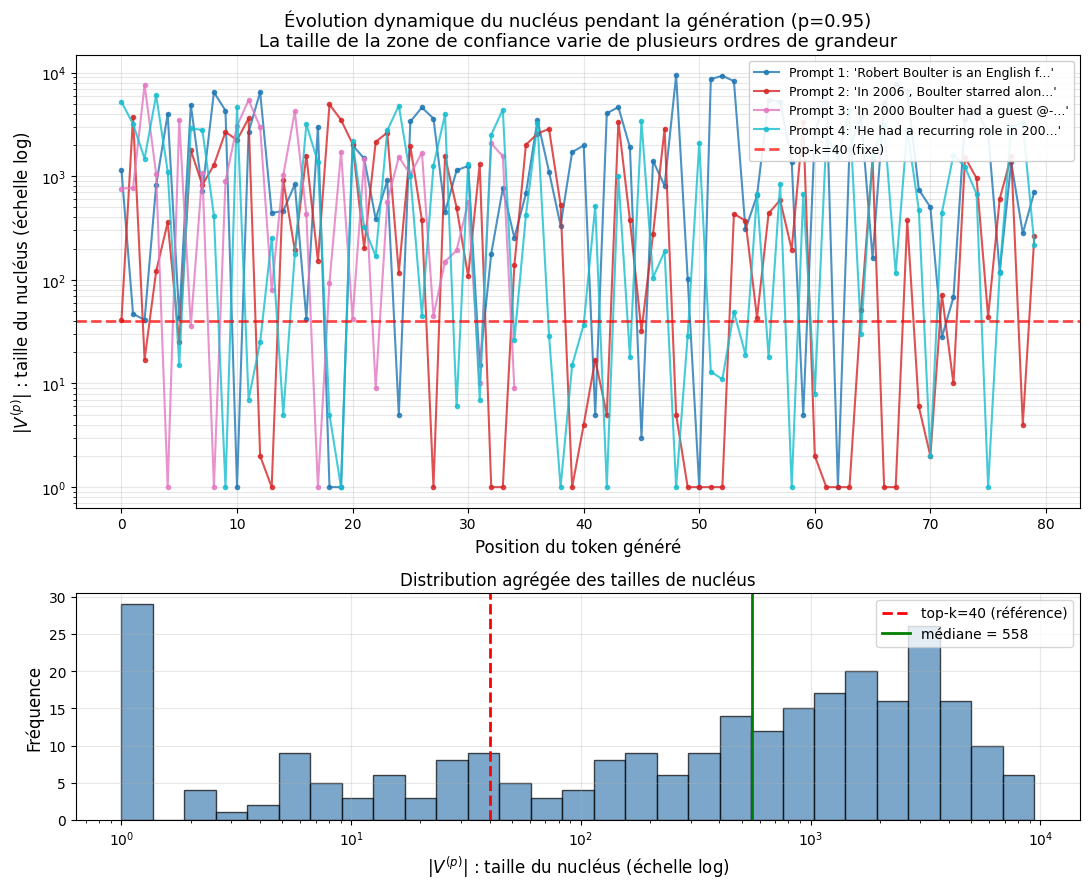


=== Statistiques agrégées (275 positions) ===
Min:    1
Max:    9413
Mean:   1409.6
Median: 558
Std:    1892.7

Fraction de positions avec |V^(p)| <= 10: 18.9%
Fraction de positions avec |V^(p)| >= 100: 68.0%


In [17]:
# Plot : taille du nucléus au cours du temps
fig, axes = plt.subplots(2, 1, figsize=(11, 9),
                          gridspec_kw={'height_ratios': [2, 1]})

# --- Panel A : évolution temporelle ---
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, len(tracking_results)))
for i, r in enumerate(tracking_results):
    # Label court
    short = r['prompt'][:30] + '...' if len(r['prompt']) > 30 else r['prompt']
    ax.plot(r['sizes'], marker='o', markersize=3, linewidth=1.5,
            color=colors[i], label=f"Prompt {i+1}: '{short}'", alpha=0.8)

# Ligne de référence pour top-k=40
ax.axhline(40, color='red', linestyle='--', linewidth=2, alpha=0.7,
           label='top-k=40 (fixe)')

ax.set_yscale('log')
ax.set_xlabel('Position du token généré', fontsize=12)
ax.set_ylabel(r'$|V^{(p)}|$ : taille du nucléus (échelle log)', fontsize=12)
ax.set_title(f'Évolution dynamique du nucléus pendant la génération (p={P_TRACK})\n'
             'La taille de la zone de confiance varie de plusieurs ordres de grandeur',
             fontsize=13)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3, which='both')

# --- Panel B : distribution globale ---
ax = axes[1]
all_sizes = [s for r in tracking_results for s in r['sizes']]
bins = np.logspace(0, np.log10(max(all_sizes) + 1), 30)
ax.hist(all_sizes, bins=bins, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xscale('log')
ax.axvline(40, color='red', linestyle='--', linewidth=2,
           label='top-k=40 (référence)')
ax.axvline(np.median(all_sizes), color='green', linestyle='-', linewidth=2,
           label=f'médiane = {int(np.median(all_sizes))}')
ax.set_xlabel(r'$|V^{(p)}|$ : taille du nucléus (échelle log)', fontsize=12)
ax.set_ylabel('Fréquence', fontsize=12)
ax.set_title('Distribution agrégée des tailles de nucléus', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nucleus_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistiques
print(f"\n=== Statistiques agrégées ({len(all_sizes)} positions) ===")
print(f"Min:    {min(all_sizes)}")
print(f"Max:    {max(all_sizes)}")
print(f"Mean:   {np.mean(all_sizes):.1f}")
print(f"Median: {int(np.median(all_sizes))}")
print(f"Std:    {np.std(all_sizes):.1f}")
print(f"\nFraction de positions avec |V^(p)| <= 10: {np.mean(np.array(all_sizes) <= 10)*100:.1f}%")
print(f"Fraction de positions avec |V^(p)| >= 100: {np.mean(np.array(all_sizes) >= 100)*100:.1f}%")

### 7.1 Analyse qualitative : quels tokens correspondent aux pics et aux creux ?

On regarde les tokens générés quand le nucléus est très petit (modèle sûr) vs très grand (modèle hésitant). C'est très illustratif pour le rapport.

In [18]:
# Pour le premier prompt, on affiche position par position le couple (taille_nucleus, token)
r = tracking_results[0]
print(f"Prompt : {r['prompt']}\n")

# Tokens avec le plus petit nucléus (modèle très sûr)
pairs = list(zip(r['sizes'], r['tokens']))
pairs_sorted_small = sorted(pairs, key=lambda x: x[0])[:5]
pairs_sorted_large = sorted(pairs, key=lambda x: -x[0])[:5]

print("5 tokens avec le PLUS PETIT nucléus (modèle quasi déterministe) :")
for size, tok in pairs_sorted_small:
    print(f"  |V^(p)|={size:4d} -> {tok!r}")

print("\n5 tokens avec le PLUS GRAND nucléus (modèle très incertain) :")
for size, tok in pairs_sorted_large:
    print(f"  |V^(p)|={size:4d} -> {tok!r}")

print("\nTexte complet généré :")
print(''.join(r['tokens']))

Prompt : Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television series The Bill in

5 tokens avec le PLUS PETIT nucléus (modèle quasi déterministe) :
  |V^(p)|=   1 -> '@'
  |V^(p)|=   1 -> '-'
  |V^(p)|=   1 -> '@'
  |V^(p)|=   1 -> ' as'
  |V^(p)|=   1 -> '@'

5 tokens avec le PLUS GRAND nucléus (modèle très incertain) :
  |V^(p)|=9413 -> ' roles'
  |V^(p)|=9298 -> ' male'
  |V^(p)|=8637 -> ' a'
  |V^(p)|=8257 -> ' p'
  |V^(p)|=7757 -> ' female'

Texte complet généré :
 August 2013. A 25% fan of @-@ is never an adventure away from @-@. He is married to Mistress Florence Pritha Pritha who is another stunt artist. Also along with Mike Vissers He play roles such as a male porter in the first half of #-@ in 2009 and the female parent in Season 1 's 999 episodes. He is currently


## 8. Conclusion et discussion pour le rapport

### Ce qu'on a montré

1. **Implémentation à partir de zéro** de Nucleus Sampling (équations 2-3 du papier) en 15 lignes utiles.
2. **Expérience 1** — Reproduction qualitative de la Figure 9 du papier : sur GPT-2 small (124M, soit 6× plus petit que le modèle du papier), on observe :
   - Greedy : taux de répétition très élevé
   - Température basse / top-k à petit k : forte répétition
   - Nucleus dans sa plage usuelle p ∈ [0.9, 0.95] : taux de répétition très bas
3. **Expérience 2** — Visualisation directe de l'argument central du papier : la taille de la zone de confiance d'un LM varie sur **plusieurs ordres de grandeur** au cours d'une génération (de 1 à >1000 tokens). Aucune valeur fixe de $k$ en top-k ne peut capturer cette variation.

### Critiques et limites

- **20 prompts seulement** : variance statistique élevée. Le papier en utilise 5000.
- **Détection au niveau mot** (pas BPE) : moins précise que le papier.
- **GPT-2 small** : la dégénération pourrait avoir une intensité différente sur un modèle moderne (instruction-tuné, RLHF).
- **On n'a pas mesuré la qualité** des générations non répétitives : nucleus peut éviter la répétition tout en produisant du contenu peu cohérent.
- **Pas d'évaluation HUSE** : on ne fait pas d'évaluation humaine, donc on ne peut pas conclure sur la qualité absolue.

### Pistes d'extension

- Refaire l'expérience sur un modèle moderne (Llama 3.2 1B, Mistral 7B quantifié 4-bit) pour voir si la dégénération persiste post-instruction-tuning.
- Comparer avec des méthodes plus récentes : typical sampling (Meister 2022), min-p sampling (Nguyen 2024).
- Mesurer également la **diversité** (Self-BLEU) en plus de la répétition, pour reproduire le trade-off qualité/diversité du papier.


## Expérience 3 : Compromis Répétition vs Incohérence

In [19]:
# =============================================================================
# Expérience 3 : Compromis Répétition vs Incohérence
# Reproduction d'une partie du Tableau 1 du papier (Holtzman et al., 2020)
# =============================================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import time

# -----------------------------------------------------------------------------
# Métriques
# -----------------------------------------------------------------------------

def get_ngrams(tokens, n):
    """Retourne la liste des n-grammes d'une séquence de tokens."""
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def repetition_rate(text, n=3):
    """rep-n = 1 - (n-grammes uniques / total n-grammes).
    Plus c'est élevé, plus le texte est répétitif. Valeurs typiques :
    - Texte humain : ~0.05-0.15
    - Greedy GPT-2 : ~0.5-0.9 (très haut, beaucoup de répétitions)
    - Nucleus p=0.95 : ~0.10-0.20 (proche humain)
    """
    tokens = text.split()
    if len(tokens) < n:
        return 0.0
    ngrams = get_ngrams(tokens, n)
    return 1.0 - len(set(ngrams)) / len(ngrams)

@torch.no_grad()
def compute_perplexity(text, model, tokenizer, device):
    """Calcule la perplexité d'un texte sous le modèle.
    Plus c'est bas, plus le modèle juge le texte 'probable' (= prévisible).
    Plus c'est haut, plus le texte contient des tokens surprenants.
    """
    encodings = tokenizer(text, return_tensors='pt').to(device)
    input_ids = encodings.input_ids
    if input_ids.shape[1] < 2:
        return float('nan')
    outputs = model(input_ids, labels=input_ids)
    return torch.exp(outputs.loss).item()

# -----------------------------------------------------------------------------
# Génération avec beam search (via HuggingFace pour la simplicité)
# -----------------------------------------------------------------------------

@torch.no_grad()
def generate_beam(prompt, num_beams=5, max_new_tokens=200):
    """Génération par beam search via l'API HuggingFace."""
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    prompt_len = input_ids.shape[1]
    output = model.generate(
        input_ids,
        max_new_tokens=max_new_tokens,
        num_beams=num_beams,
        do_sample=False,
        early_stopping=True,
        no_repeat_ngram_size=0,  # désactivé pour observer la dégénération naturelle
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(output[0, prompt_len:], skip_special_tokens=True)

# -----------------------------------------------------------------------------
# Boucle expérimentale
# -----------------------------------------------------------------------------

# On utilise les prompts WikiText déjà chargés (réutiliser PROMPTS si disponible,
# sinon recharger). Réduire à 25 pour rester rapide.
EXPERIMENT_PROMPTS = PROMPTS[:25]
MAX_NEW = 200

methods_to_test = [
    ('Beam (b=5)',       'beam',    {'num_beams': 5}),
    ('Greedy',           'greedy',  {}),
    ('Top-k (k=40)',     'topk',    {'k': 40}),
    ('Nucleus (p=0.95)', 'nucleus', {'p': 0.95}),
    ('Temp (t=0.7)',     'temperature', {'temperature': 0.7}),
    ('Pure sampling',    'sampling', {}),
]

results_tradeoff = {label: {'rep': [], 'ppl': []} for label, _, _ in methods_to_test}

t_start = time.time()
for m_idx, (label, method, params) in enumerate(methods_to_test):
    print(f"\n[{m_idx+1}/{len(methods_to_test)}] {label}")
    for p_idx, prompt in enumerate(EXPERIMENT_PROMPTS):
        torch.manual_seed(SEED + p_idx)

        # Génération
        if method == 'beam':
            text = generate_beam(prompt, max_new_tokens=MAX_NEW, **params)
        else:
            text = generate(prompt, method, max_new_tokens=MAX_NEW, **params)

        # Métriques
        rep = repetition_rate(text, n=3)
        ppl = compute_perplexity(prompt + ' ' + text, model, tokenizer, device)

        results_tradeoff[label]['rep'].append(rep)
        results_tradeoff[label]['ppl'].append(ppl)

    # Stats résumées
    mean_rep = np.mean(results_tradeoff[label]['rep'])
    mean_ppl = np.mean(results_tradeoff[label]['ppl'])
    print(f"  rep-3 moyen = {mean_rep:.3f} | PPL moyenne = {mean_ppl:.2f}")
    print(f"  Temps écoulé : {(time.time()-t_start)/60:.1f} min")

# -----------------------------------------------------------------------------
# Baseline humaine : perplexité et répétition d'un texte naturel
# -----------------------------------------------------------------------------

human_reps, human_ppls = [], []
for ex in ds.select(range(200)):
    text = ex['text'].strip()
    if len(text.split()) < 100 or text.startswith('='):
        continue
    # Tronquer à environ 200 tokens pour comparable
    truncated = ' '.join(text.split()[:200])
    human_reps.append(repetition_rate(truncated, n=3))
    human_ppls.append(compute_perplexity(truncated, model, tokenizer, device))
    if len(human_reps) >= 25:
        break

human_rep_mean = np.mean(human_reps)
human_ppl_mean = np.mean(human_ppls)
print(f"\n=== Baseline humaine (WikiText) ===")
print(f"rep-3 = {human_rep_mean:.3f} | PPL = {human_ppl_mean:.2f}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



[1/6] Beam (b=5)


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  rep-3 moyen = 0.699 | PPL moyenne = 4.13
  Temps écoulé : 1.7 min

[2/6] Greedy
  rep-3 moyen = 0.674 | PPL moyenne = 2.91
  Temps écoulé : 5.1 min

[3/6] Top-k (k=40)
  rep-3 moyen = 0.032 | PPL moyenne = 16.87
  Temps écoulé : 8.4 min

[4/6] Nucleus (p=0.95)
  rep-3 moyen = 0.008 | PPL moyenne = 52.21
  Temps écoulé : 11.4 min

[5/6] Temp (t=0.7)
  rep-3 moyen = 0.121 | PPL moyenne = 11.32
  Temps écoulé : 14.6 min

[6/6] Pure sampling
  rep-3 moyen = 0.003 | PPL moyenne = 78.25
  Temps écoulé : 17.6 min

=== Baseline humaine (WikiText) ===
rep-3 = 0.014 | PPL = 40.07


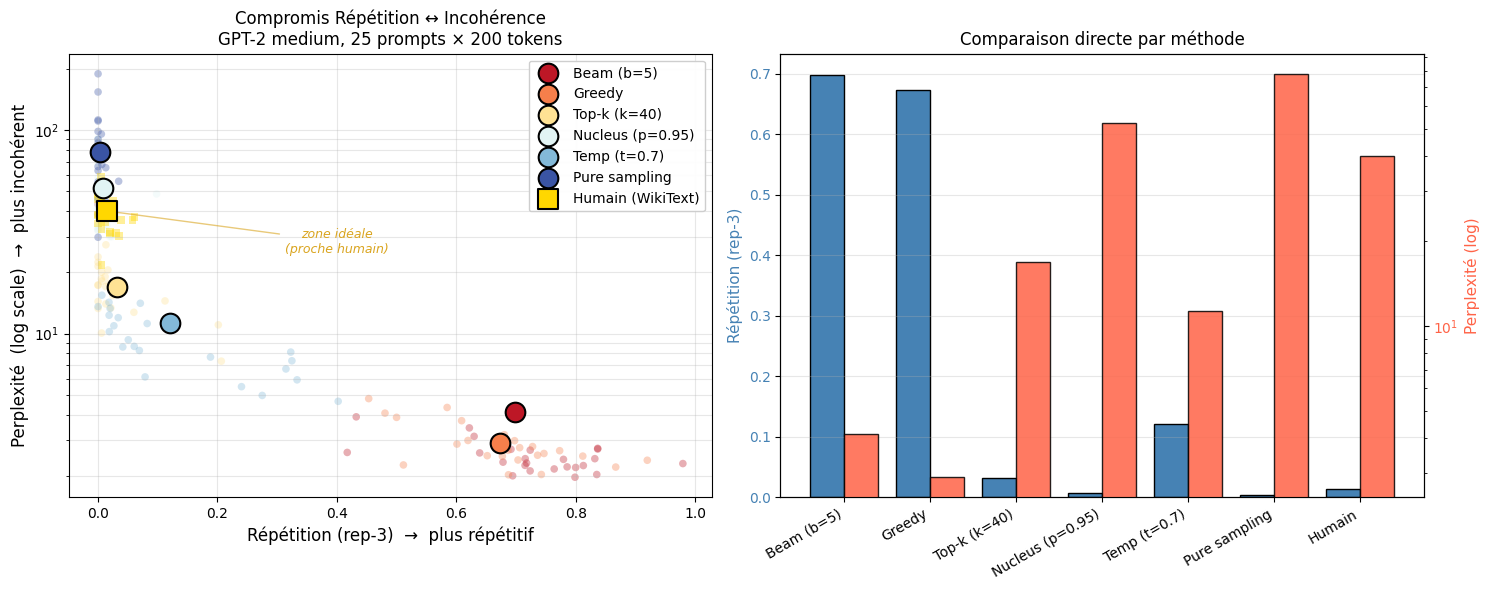


=== Tableau récapitulatif ===
Méthode                   rep-3      PPL
----------------------------------------
Beam (b=5)                0.699     4.13
Greedy                    0.674     2.91
Top-k (k=40)              0.032    16.87
Nucleus (p=0.95)          0.008    52.21
Temp (t=0.7)              0.121    11.32
Pure sampling             0.003    78.25
Humain (WikiText)         0.014    40.07


In [20]:
# =============================================================================
# Plot du compromis Répétition vs Incohérence
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -----------------------------------------------------------------------------
# Panel A : Scatter plot 2D (le plot principal)
# -----------------------------------------------------------------------------
ax = axes[0]
colors = plt.cm.RdYlBu(np.linspace(0.05, 0.95, len(methods_to_test)))

for (label, _, _), color in zip(methods_to_test, colors):
    rep = results_tradeoff[label]['rep']
    ppl = results_tradeoff[label]['ppl']
    # Points individuels (transparents) + moyenne (gros marqueur)
    ax.scatter(rep, ppl, color=color, s=30, alpha=0.35, edgecolor='none')
    ax.scatter([np.mean(rep)], [np.mean(ppl)], color=color, s=200,
               edgecolor='black', linewidth=1.5, label=label, zorder=10)

# Baseline humaine
ax.scatter(human_reps, human_ppls, color='gold', s=30, alpha=0.4,
           edgecolor='none', marker='s')
ax.scatter([human_rep_mean], [human_ppl_mean], color='gold', s=200,
           edgecolor='black', linewidth=1.5, marker='s',
           label='Humain (WikiText)', zorder=10)

ax.set_yscale('log')
ax.set_xlabel('Répétition (rep-3)  →  plus répétitif', fontsize=12)
ax.set_ylabel('Perplexité  (log scale)  →  plus incohérent', fontsize=12)
ax.set_title('Compromis Répétition ↔ Incohérence\n'
             f'GPT-2 medium, {len(EXPERIMENT_PROMPTS)} prompts × {MAX_NEW} tokens',
             fontsize=12)
ax.grid(True, alpha=0.3, which='both')
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)

# Annotations des zones
ax.annotate('zone idéale\n(proche humain)', xy=(human_rep_mean, human_ppl_mean),
            xytext=(0.4, 25), fontsize=9, ha='center',
            color='goldenrod', style='italic',
            arrowprops=dict(arrowstyle='->', color='goldenrod', alpha=0.6))

# -----------------------------------------------------------------------------
# Panel B : Bar chart côte-à-côte des deux métriques
# -----------------------------------------------------------------------------
ax = axes[1]
labels_only = [m[0] for m in methods_to_test] + ['Humain']
rep_means = [np.mean(results_tradeoff[m[0]]['rep']) for m in methods_to_test] + [human_rep_mean]
ppl_means = [np.mean(results_tradeoff[m[0]]['ppl']) for m in methods_to_test] + [human_ppl_mean]

x = np.arange(len(labels_only))
width = 0.4

# Répétition à gauche
bars1 = ax.bar(x - width/2, rep_means, width, color='steelblue',
               edgecolor='black', label='Répétition (rep-3)')
ax.set_ylabel('Répétition (rep-3)', color='steelblue', fontsize=11)
ax.tick_params(axis='y', labelcolor='steelblue')

# Perplexité à droite (axe secondaire, log)
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, ppl_means, width, color='tomato',
                edgecolor='black', label='Perplexité', alpha=0.85)
ax2.set_ylabel('Perplexité (log)', color='tomato', fontsize=11)
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='tomato')

ax.set_xticks(x)
ax.set_xticklabels(labels_only, rotation=30, ha='right')
ax.set_title('Comparaison directe par méthode', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tradeoff_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------------
# Tableau récapitulatif (utile pour le rapport)
# -----------------------------------------------------------------------------
print("\n=== Tableau récapitulatif ===")
print(f"{'Méthode':<22} {'rep-3':>8} {'PPL':>8}")
print("-" * 40)
for label, _, _ in methods_to_test:
    rep_m = np.mean(results_tradeoff[label]['rep'])
    ppl_m = np.mean(results_tradeoff[label]['ppl'])
    print(f"{label:<22} {rep_m:>8.3f} {ppl_m:>8.2f}")
print(f"{'Humain (WikiText)':<22} {human_rep_mean:>8.3f} {human_ppl_mean:>8.2f}")